In [1]:
from shapely.constructive import make_valid
from shapely.geometry import Polygon, Point
from shapely.plotting import plot_polygon, plot_points
import matplotlib.pyplot as plt
import os
import sys

# Agregar el directorio raíz del proyecto al sys.path
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(project_root)

# Ahora puedes importar src.utils
from src import utils as ut

# Polygon validation

This notebook validates if the polygons inside model_files and bna_volcanic_fils are valid. The reason for this is that the polygons are used to mask the data and if they are not valid, the masking will not work. Let's start by importing the necessary libraries and loading the data.

In [2]:
path = "../model_files"

# iterate through all file
for file in os.listdir(path):
    # Check whether file is in text format or not
    if file.endswith(".txt"):
        file_path = rf"{path}\{file}"
        print(file_path)

../model_files\zona3.txt
../model_files\Modelo_Cesar.txt
../model_files\zona2.txt
../model_files\zona_PtoGaitan.txt
../model_files\example.txt
../model_files\zona5.txt
../model_files\zona_vmm.txt
../model_files\zona4.txt
../model_files\zona1.txt
../model_files\Modelo_CARMA.txt
../model_files\colom_ecu_fro.txt


In [3]:
volcanic_path = "../bna_volcanic_files"

# iterate through all file
for file in os.listdir(volcanic_path):
    # Check whether file is in text format or not
    if file.endswith(".txt"):
        file_path = rf"{path}\{file}"
        print(file_path)

../model_files\obspopvnh.txt
../model_files\obspas3.txt
../model_files\obspas9.txt
../model_files\obsman.txt
../model_files\obspas7.txt
../model_files\obspas1.txt
../model_files\obspas5.txt
../model_files\obspas8.txt
../model_files\obspop.txt
../model_files\obspas4.txt
../model_files\obspas6.txt
../model_files\obspas2.txt


In [9]:
# Read the model file for both regular and volcanic zones
volcanic_data = {}
zone_data = {}
model_folder = "../model_files"
bna_folder = "../bna_volcanic_files"
ut.model_reader(model_folder, zone_data, re_order=False)
ut.model_reader(bna_folder, volcanic_data)

In [10]:
print(volcanic_data.keys())
print(zone_data.keys())

dict_keys(['obspopvnh.txt', 'obspas3.txt', 'obspas9.txt', 'obsman.txt', 'obspas7.txt', 'obspas1.txt', 'obspas5.txt', 'obspas8.txt', 'obspop.txt', 'obspas4.txt', 'obspas6.txt', 'obspas2.txt'])
dict_keys(['zona3.txt', 'Modelo_Cesar.txt', 'zona2.txt', 'zona_PtoGaitan.txt', 'example.txt', 'zona5.txt', 'zona_vmm.txt', 'zona4.txt', 'zona1.txt', 'Modelo_CARMA.txt', 'colom_ecu_fro.txt'])


# Using shapely to validate the polygons

Let's start by validating the polygons in the model files:

In [11]:
example = zone_data['colom_ecu_fro.txt']
example

array([[-78.        ,  12.        ],
       [-78.07668259,  12.32279413],
       [-78.81998205,  12.32182376],
       ...,
       [-80.        ,   8.        ],
       [-78.        ,   8.        ],
       [-78.        ,  12.        ]])

Is the polygon valid? False


Text(0, 0.5, 'Latitude')

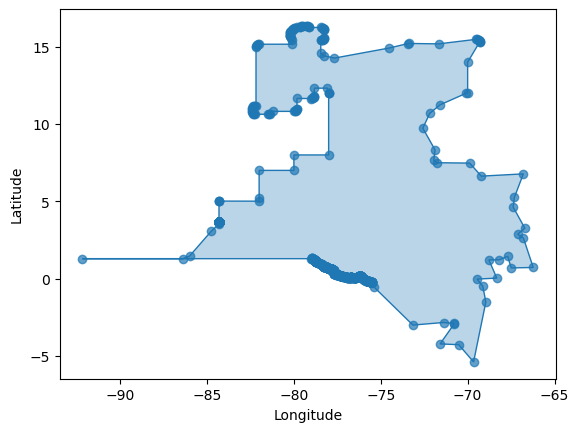

In [12]:
# Define polygon
polygon = Polygon(example)
# Check if the polygon is valid
is_valid = polygon.is_valid
print("Is the polygon valid?", is_valid)

fig, ax = plt.subplots()
plot_polygon(polygon, ax=ax, add_points=False)
plot_points(polygon, ax=ax, alpha=0.7)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

In [13]:
# Now let's validate the polygons in the model files:

for file, polygon in zone_data.items():
    polygon = Polygon(polygon)
    is_valid = polygon.is_valid
    if not is_valid:
        print(f"The polygon in {file} is not valid.")
    else:
        print(f"The polygon is {file} is valid.")

The polygon is zona3.txt is valid.
The polygon is Modelo_Cesar.txt is valid.
The polygon is zona2.txt is valid.
The polygon is zona_PtoGaitan.txt is valid.
The polygon is example.txt is valid.
The polygon is zona5.txt is valid.
The polygon is zona_vmm.txt is valid.
The polygon is zona4.txt is valid.
The polygon is zona1.txt is valid.
The polygon is Modelo_CARMA.txt is valid.
The polygon in colom_ecu_fro.txt is not valid.


In [14]:
# Now let's validate the polygons in the volcanic files:

for file, polygon in volcanic_data.items():
    polygon = Polygon(polygon)
    is_valid = polygon.is_valid
    if not is_valid:
        print(f"The polygon in {file} is not valid.")
    else:
        print(f"The polygon is {file} is valid.")

The polygon is obspopvnh.txt is valid.
The polygon is obspas3.txt is valid.
The polygon is obspas9.txt is valid.
The polygon is obsman.txt is valid.
The polygon is obspas7.txt is valid.
The polygon is obspas1.txt is valid.
The polygon is obspas5.txt is valid.
The polygon is obspas8.txt is valid.
The polygon is obspop.txt is valid.
The polygon is obspas4.txt is valid.
The polygon is obspas6.txt is valid.
The polygon is obspas2.txt is valid.


As you can see, there are two polygons that are not valid (obspopvnh.txt and obspas3.txt). Let's try to make them valid by using the buffer method. This method will create a buffer around the polygon, and then we can check if the new polygon is valid.

In [10]:
cases = ['obspopvnh.txt', 'obspas3.txt']

for file in cases:
    polygon = Polygon(volcanic_data[file])
    is_valid = polygon.is_valid
    print(f"The polygon in {file} is valid? {is_valid}")
    if not is_valid:
        # Create a buffer around the polygon
        buffered_polygon = polygon.buffer(0)
        is_valid = buffered_polygon.is_valid
        print(f"Is the buffered polygon valid? {is_valid}")
        if not is_valid:
            polygon = make_valid(polygon)
            is_valid = polygon.is_valid
            print(f"Is the make_valid polygon valid? {is_valid}")
        else:
            # Update the coordinates in the dict
            volcanic_data[file] = list(buffered_polygon.exterior.coords)

The polygon in obspopvnh.txt is valid? True
The polygon in obspas3.txt is valid? True


In [16]:
case = 'colom_ecu_fro.txt'
polygon = Polygon(zone_data[case])
is_valid = polygon.is_valid
print(f"The polygon in {file} is valid? {is_valid}")
if not is_valid:
    # Create a buffer around the polygon
    buffered_polygon = polygon.buffer(0)
    is_valid = buffered_polygon.is_valid
    print(f"Is the buffered polygon valid? {is_valid}")
    if not is_valid:
        polygon = make_valid(polygon)
        is_valid = polygon.is_valid
        print(f"Is the make_valid polygon valid? {is_valid}")
    else:
        zone_data[case] = list(buffered_polygon.exterior.coords)

The polygon in obspas2.txt is valid? False
Is the buffered polygon valid? True


In [18]:
with open('../model_files/colom_ecu_fro.txt', 'w') as f:
    for coord in zone_data['colom_ecu_fro.txt']:
        f.write(f"{coord[0]},{coord[1]}\n")

In [11]:
# Save in file the new redefined routine
with open('../bna_volcanic_files/obspas3.txt', 'w') as f:
    for coord in volcanic_data['obspas3.txt']:
        f.write(f"{coord[0]},{coord[1]}\n")

with open('../bna_volcanic_files/obspopvnh.txt', 'w') as f:
    for coord in volcanic_data['obspopvnh.txt']:
        f.write(f"{coord[0]},{coord[1]}\n")

Is the polygon valid? True


Text(0, 0.5, 'Latitude')

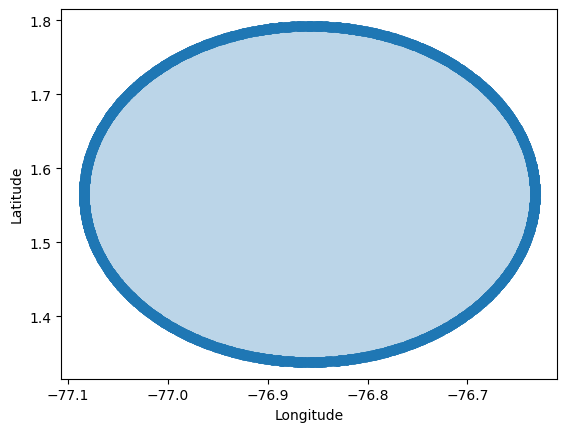

In [12]:
# Define polygon
polygon = Polygon(volcanic_data['obspas3.txt'])
# Check if the polygon is valid
is_valid = polygon.is_valid
print("Is the polygon valid?", is_valid)

fig, ax = plt.subplots()
plot_polygon(polygon, ax=ax, add_points=False)
plot_points(polygon, ax=ax, alpha=0.7)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# Special cases

After validating the polygons, we want to test special events that lies inside the polygons. For this, we will define a point inside the polygon and check if it is inside the polygon.

# Test case # 1: Santa Rosa Cauca Event

In [13]:
point = (-76.653167, 1.550833)
polygon = Polygon(volcanic_data['obspas3.txt'])
is_valid = polygon.is_valid
print("Is the polygon valid?", is_valid)
print("Is the point inside the polygon?", polygon.contains(Point(point)))

Is the polygon valid? True
Is the point inside the polygon? True


As you can see, after correcting the polygon, the point is inside the polygon!

# Test case # 2: VMM event

The event from El Playón Santander in 2025-04-04 05:47 UTC is a special case where, by changing slightly the coordinates, the event is inside the polygon incorrectly. Let's try with 3 different combinations of coordinates:

Is the polygon valid? True
Is the point case1 inside the polygon? False
Is the point case2 inside the polygon? False
Is the point case3 inside the polygon? True


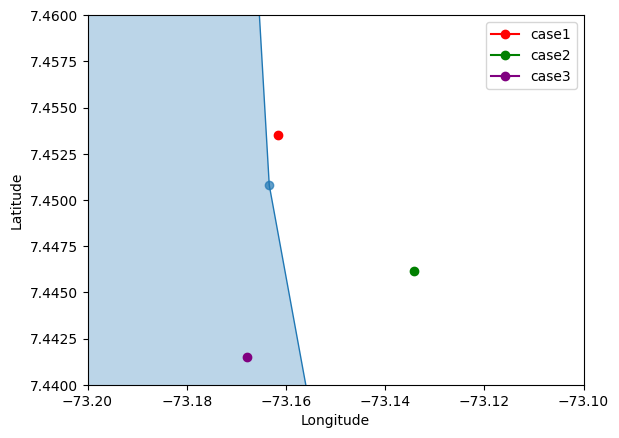

In [14]:
vmm_coords = {'case1': (-73.1615, 7.4535), 'case2': (-73.134167, 7.446167), 'case3': (-73.167833, 7.4415)}
colors = ['red', 'green', 'purple']
polygon = Polygon(zone_data['zona_vmm.txt'])
is_valid = polygon.is_valid
print("Is the polygon valid?", is_valid)

fig, ax = plt.subplots()
plot_polygon(polygon, ax=ax, add_points=False)
plot_points(polygon, ax=ax, alpha=0.7)
for case, coords in vmm_coords.items():
    point = Point(coords)
    print(f"Is the point {case} inside the polygon? {polygon.contains(Point(coords))}")
    ax.plot(coords[0], coords[1], label=case, color=colors.pop(0), marker='o')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_xlim(-73.2, -73.1)
ax.set_ylim(7.44, 7.46)
ax.legend()